<a href="https://colab.research.google.com/github/antudev/SSCarFight/blob/main/M5L1pythonpro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
122 * 76543

9338246

# Instalación de las bibliotecas

In [ ]:
!pip install rembg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.0 MB/s eta 0:00:00


In [ ]:
# Necesario para que la biblioteca rembg funcione correctamente
!pip install Pillow==9.0.0

# Importar las bibliotecas


In [ ]:
from rembg import remove
import numpy as np
from google.colab.patches import cv2_imshow
import cv2

# Cargar las imágenes

In [ ]:
from google.colab import files

# Subir las imágenes
uploaded1 = files.upload()
uploaded2 = files.upload()

# Eliminar el fondo de images.jpg

Puede obtener más información en la documentación de la biblioteca

El resultado se guarda en output.png

In [ ]:
input_path = './images.jpg'
output_path = 'output.png'

with open(input_path, 'rb') as i:
    with open(output_path, 'wb') as o:
        input = i.read()
        output = remove(input)
        o.write(output)

In [ ]:
# Así es como puede imprimir una imagen en una celda
cv2_imshow(cv2.imread('output.png'))

# Sustituir el fondo negro de una imagen





In [ ]:
def change_back(background, img):
    """ Función que sustituye el fondo negro de las imágenes por otra imagen.
    Acepta dos argumentos: la imagen de fondo (background) y la propia imagen (img).
    La función partirá de la esquina superior izquierda de la imagen. Buscará todos los píxeles negros (con el valor 0)
    y los sustituirá por píxeles de la imagen de fondo"""

    x, y = 0, 0
    background = cv2.resize(background, (img.shape[1], img.shape[0]), interpolation = cv2.INTER_AREA)
    res = np.copy(background)
    place = res[y: y + img.shape[0], x: x + img.shape[1]]
    a = img[..., 3:].repeat(3, axis=2).astype('uint16')
    place[...] = (place.astype('uint16') * (255 - a) // 255) + img[..., :3].astype('uint16') * a // 255
    return res

In [ ]:
image = cv2.imread('output.png', cv2.IMREAD_UNCHANGED)
back = cv2.imread('/content/background.jpg')
result = change_back(back, image)

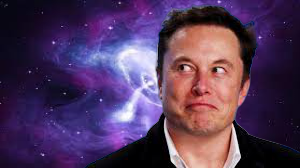

In [ ]:
cv2_imshow(result)

In [ ]:
cv2.imwrite("result.png", result)

True